# 6. 뇌 MRI 종양 분할 (LGG) — 이진 분할

수업에서 다룬 2~5번 노트북을 조합해 구성한다.
각 절 머리에 **어느 노트북에서 가져왔는지** 표시했다.

| 출처 | 가져온 것 |
|---|---|
| **2번** CNN | `BatchNorm2d`, `Dropout`, 가중치 초기화, `CosineAnnealingLR`, seaborn 혼동행렬 |
| **4번** 전이학습 | 이진 출력(`Linear(...,1)`), `evaluation()` 구조, recall·precision·ROC-AUC, 데이터 분할 |
| **5번** 분할 | `build_dataset`, `SegDataset`, `conv2d_block`/`EncoderBlock`/`DecoderBlock`/`UNet`, `train_unet`, history |
| **신규** | 환자 단위 분할, 빈 슬라이스 재샘플링, Dice·Tversky 손실, 임계값 분석, 가설검정 |

### 5번(Cityscapes)에서 바뀌는 지점

| | 5번 | 이번 |
|---|---|---|
| 출력 채널 | 30 | **1** (4번의 이진 출력 방식) |
| 손실 | `CrossEntropyLoss` | **BCE + Dice / Tversky** |
| 마스크 | int64 `(B,H,W)` | **float32 `(B,1,H,W)`** |
| 예측 | `argmax(1)` | **`sigmoid() > threshold`** (4번 방식) |
| 지표 | mIoU, pixel acc | **Dice + recall** |
| `encode_mask` | 필요 | **불필요** (마스크가 이미 0/255) |

**임상 전제** — 의사가 환자 1명의 MRI를 판독하는 상황.
지표 극대화가 아니라 놓친 종양 최소화가 목적.

---
## 0. 준비

**[2~5번 공통]** import, 시드 고정, device 설정, 한글 폰트.

device 부분만 확장했다. 2~5번은 `cuda`만 확인하는데,
`hasattr` 가드와 GPU 정보 출력을 추가했다.

In [1]:
import os, time, json, platform
from glob import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# [4번] 이진 분류 지표 — 흉부 X-ray에서 쓴 것과 같은 import
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

# 한글 폰트 설정 (윈도우)  [2~5번 공통]
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("torch:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU  :", torch.cuda.get_device_name(0))
    print("VRAM :", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")
else:
    print("[경고] GPU 미사용. 에폭당 30분 이상 걸립니다.")

torch: 2.11.0+cu128
device: cuda
GPU  : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM : 8.0 GB


### 0-1. 하이퍼파라미터

**[2번]** `batch_size`, `image_size`, `learning_rate`, `epochs`를 한곳에 모으는 방식.

`IMAGE_SIZE`는 **256에서 내리지 말 것.** 이 데이터의 최소 종양이 약 7픽셀이라
128로 줄이면 2픽셀이 되고, nearest 리사이즈에서 사라지는 슬라이스가 생긴다.

In [ ]:
IMAGE_SIZE = 256
BASE       = 32        # U-Net 첫 채널 수. 속도 측정 후 결정 (64/32/16)
BATCH_SIZE = 16
EPOCHS     = 30
LR         = 1e-3
NEG_RATIO  = 1.0       # 종양 1장당 빈 슬라이스 몇 장을 섞을지

USE_AMP     = (device.type == "cuda")   # 혼합정밀도 — 1.5~2배 가속
PIN_MEMORY  = (device.type == "cuda")
NUM_WORKERS = 0        # 윈도우 주피터는 0이 안전 (데이터를 RAM에 올리므로 손해 없음)

print(f"BASE={BASE} BATCH={BATCH_SIZE} EPOCHS={EPOCHS} "
      f"NEG_RATIO={NEG_RATIO} AMP={USE_AMP}")

BASE=32 BATCH=16 EPOCHS=30 NEG_RATIO=1.0 AMP=True


### 0-2. 실행 환경 기록

**[신규]** 보고서의 재현성 항목용. `env.json`으로 저장한다.

In [3]:
import sklearn, matplotlib

ENV = {
    "OS": f"{platform.system()} {platform.release()}",
    "Python": platform.python_version(),
    "torch": torch.__version__, "CUDA": torch.version.cuda,
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음",
    "numpy": np.__version__, "pandas": pd.__version__,
    "opencv": cv2.__version__, "sklearn": sklearn.__version__,
    "matplotlib": matplotlib.__version__, "SEED": SEED,
}
for k, v in ENV.items():
    print(f"  {k:11s}: {v}")
with open("env.json", "w", encoding="utf-8") as f:
    json.dump(ENV, f, ensure_ascii=False, indent=2)

  OS         : Windows 10
  Python     : 3.10.11
  torch      : 2.11.0+cu128
  CUDA       : 12.8
  GPU        : NVIDIA GeForce RTX 5060 Laptop GPU
  numpy      : 1.26.4
  pandas     : 2.3.3
  opencv     : 4.11.0
  sklearn    : 1.7.2
  matplotlib : 3.10.9
  SEED       : 42


---
## 1. 데이터 인덱싱

**[5번 변형]** 5번은 `train_dir`/`val_dir` 폴더가 이미 나뉘어 있어서
`glob(f"{train_dir}*.jpg")` 한 줄이면 됐다.
여기는 환자 폴더 110개가 섞여 있으므로 파일 목록을 데이터프레임으로 만든다.

`glob`으로 **마스크를 먼저** 잡고 `_mask`를 떼어 원본 경로를 만든다.
원본을 먼저 잡으면 마스크까지 같이 걸려서 걸러내야 한다.

In [4]:
# 이 데이터셋의 기댓값 (Kaggle LGG Segmentation, TCIA/TCGA-LGG)
EXPECT_PATIENTS, EXPECT_IMAGES, EXPECT_MASKS = 110, 3929, 3929

cands = sorted(glob("**/kaggle_3m", recursive=True))
if not cands:
    raise FileNotFoundError(
        f"kaggle_3m 폴더를 못 찾았습니다.\n작업 디렉토리: {os.getcwd()}")
if len(cands) > 1:
    print(f"[주의] kaggle_3m 폴더가 {len(cands)}개 발견됨 — 중복 압축 해제")
    for c in cands: print("   ", c)

ROOT = cands[0]
print("ROOT =", ROOT)

# --- 무결성 검증 [신규] ---
n_patients = len(glob(os.path.join(ROOT, "TCGA_*")))
all_tif    = glob(os.path.join(ROOT, "*", "*.tif"))
n_masks    = len([p for p in all_tif if p.endswith("_mask.tif")])
n_images   = len(all_tif) - n_masks
print(f"환자 {n_patients} / 원본 {n_images} / 마스크 {n_masks}")

problems = []
if n_patients != EXPECT_PATIENTS: problems.append(f"환자 {n_patients} (기대 {EXPECT_PATIENTS})")
if n_images   != EXPECT_IMAGES:   problems.append(f"원본 {n_images} (기대 {EXPECT_IMAGES})")
if n_masks    != EXPECT_MASKS:    problems.append(f"마스크 {n_masks} (기대 {EXPECT_MASKS})")
if n_images   != n_masks:         problems.append("원본과 마스크 개수 불일치")
if problems:
    raise ValueError("무결성 검증 실패:\n  - " + "\n  - ".join(problems))
print("[검증 통과]\n")

# --- 인덱스 구성 ---
records = []
for mask_path in glob(os.path.join(ROOT, "*", "*_mask.tif")):
    img_path = mask_path.replace("_mask.tif", ".tif")
    patient  = os.path.basename(os.path.dirname(mask_path))
    slice_no = int(os.path.basename(img_path).split("_")[-1].replace(".tif", ""))
    records.append({"patient": patient, "slice": slice_no,
                    "image": img_path, "mask": mask_path})

df = pd.DataFrame(records).sort_values(["patient", "slice"]).reset_index(drop=True)
df["inst"] = df["patient"].str.split("_").str[1]      # 촬영 기관 코드
print(f"슬라이스 {len(df)} / 환자 {df['patient'].nunique()} / 기관 {df['inst'].nunique()}")

ROOT = archive\kaggle_3m
환자 110 / 원본 3929 / 마스크 3929
[검증 통과]

슬라이스 3929 / 환자 110 / 기관 5


### 1-1. 클래스 분포 확인

**[4번]** 흉부 X-ray에서 `NORMAL`/`PNEUMONIA` 장수를 세어 불균형을 확인했던 것과 같다.
다만 여기는 **슬라이스 단위 불균형**과 **픽셀 단위 불균형**이 따로 있다.

In [5]:
def tumor_stats(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return pd.Series({"tumor": int(m.max() > 0), "tumor_px": int((m > 0).sum())})

df = df.join(df["mask"].apply(tumor_stats))

print("[슬라이스 단위]")
print(df["tumor"].value_counts(normalize=True).round(3))
print()
print("[픽셀 단위]")
print("전체 픽셀 중 종양:",
      round(df["tumor_px"].sum() / (len(df) * IMAGE_SIZE**2) * 100, 3), "%")
print()
print("종양 슬라이스의 종양 비중(%)")
print((df.loc[df.tumor == 1, "tumor_px"] / IMAGE_SIZE**2 * 100).describe().round(2))

[슬라이스 단위]
tumor
0    0.651
1    0.349
Name: proportion, dtype: float64

[픽셀 단위]
전체 픽셀 중 종양: 1.03 %

종양 슬라이스의 종양 비중(%)
count    1373.00
mean        2.95
std         2.33
min         0.01
25%         1.12
50%         2.33
75%         4.22
max        12.10
Name: tumor_px, dtype: float64


**전체 픽셀의 1% 정도만 종양이다.** 이 한 줄이 이후 모든 설계의 근거가 된다.

- 픽셀 정확도는 무의미 → Dice와 recall을 쓴다
- BCE 단독은 "전부 배경"으로 수렴 → Dice 항을 섞는다
- 빈 슬라이스 65%를 그대로 넣으면 학습이 희석 → 에폭마다 샘플링한다

In [6]:
# 파일 수준 중복 — 빈 마스크는 내용이 전부 동일하다  [신규]
n_empty = int((df["tumor"] == 0).sum())
n_pos   = int((df["tumor"] == 1).sum())
print(f"tif 파일 총           {len(df)*2:,}개")
print(f"내용이 다른 파일       {len(df) + n_pos + 1:,}개")
print(f"  원본 이미지         {len(df):,}개 (전부 고유)")
print(f"  종양 마스크         {n_pos:,}개 (전부 고유)")
print(f"  빈 마스크           {n_empty:,}개 (전부 동일, 256x256 전부 0)")
print(f"\n-> 빈 마스크 비율 {n_empty/len(df):.1%} 가 곧 클래스 불균형이다")

tif 파일 총           7,858개
내용이 다른 파일       5,303개
  원본 이미지         3,929개 (전부 고유)
  종양 마스크         1,373개 (전부 고유)
  빈 마스크           2,556개 (전부 동일, 256x256 전부 0)

-> 빈 마스크 비율 65.1% 가 곧 클래스 불균형이다


### 1-2. 촬영 기관별 분포

**[신규]** 환자 ID에 기관 코드가 들어있다 (`TCGA_<기관>_<번호>_<날짜>`).
기관마다 스캐너와 프로토콜이 달라 영상 밝기가 다르다.
**분할 층화 기준으로 쓴다.**

In [7]:
g = df.groupby("inst").agg(환자수=("patient", "nunique"),
                           슬라이스=("patient", "size"),
                           종양비율=("tumor", "mean")).sort_values("환자수", ascending=False)

rows = []
for inst, sub in df.groupby("inst"):
    vals = []
    for p in sub.groupby("patient").head(3)["image"]:
        f = cv2.imread(p, cv2.IMREAD_UNCHANGED)[:, :, ::-1][:, :, 1] / 255.0
        brain = f > 0.05
        if brain.sum() > 0: vals.append(f[brain].mean())
    rows.append({"inst": inst, "FLAIR평균밝기": np.mean(vals)})

print(g.join(pd.DataFrame(rows).set_index("inst")).round(4))

      환자수  슬라이스    종양비율  FLAIR평균밝기
inst                              
DU     45  1878  0.3323     0.1905
HT     34  1029  0.3926     0.2363
CS     16   358  0.3380     0.2445
FG     14   640  0.3406     0.2396
EZ      1    24  0.2500     0.2506


### 1-3. 눈으로 확인

**[5번]** "눈으로 확인하기(데이터셋 나누고 난 후에)" 셀과 같은 방식.
5번은 `원본 / 정답 마스크 / 클래스 번호` 3열이었는데,
여기는 **3채널이 서로 다른 촬영 기법**이므로 채널을 펼쳐서 본다.

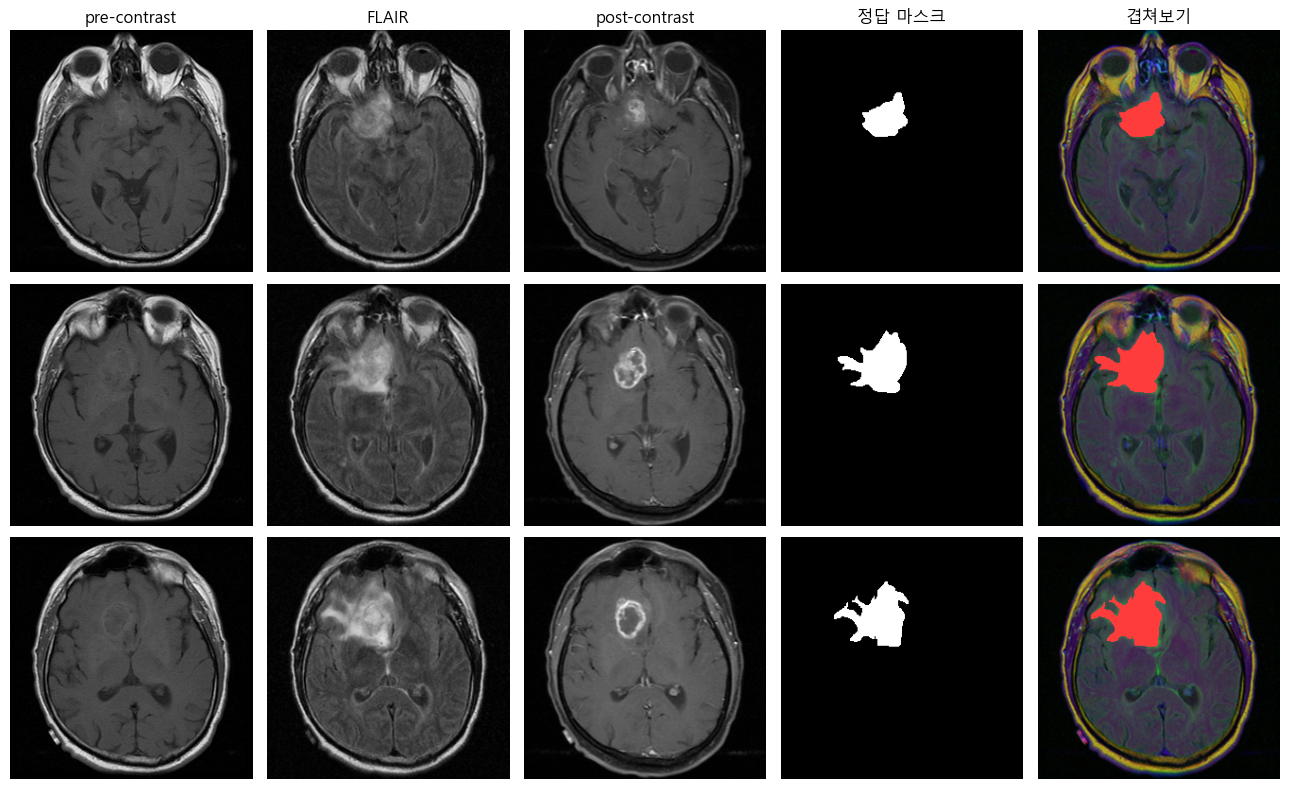

In [8]:
idx = df.index[df.tumor == 1][:3]
plt.figure(figsize=(13, 8))
for r, i in enumerate(idx):
    img = cv2.imread(df.loc[i, "image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
    msk = (cv2.imread(df.loc[i, "mask"], 0) > 127).astype(np.uint8)
    ov = img.copy(); ov[msk > 0] = [255, 60, 60]
    for j, (arr, t) in enumerate([(img[:,:,0], "pre-contrast"), (img[:,:,1], "FLAIR"),
                                  (img[:,:,2], "post-contrast"), (msk, "정답 마스크"),
                                  (ov, "겹쳐보기")]):
        plt.subplot(3, 5, r*5 + j + 1)
        plt.imshow(arr, cmap="gray" if arr.ndim == 2 else None)
        plt.axis("off")
        if r == 0: plt.title(t)
plt.tight_layout(); plt.show()

---
## 2. 데이터 분할

**[4번 변형]** 4번에서는 `torch.randperm`으로 인덱스를 섞어 8:2로 나눴다.

```python
perm = torch.randperm(n_total, generator=g).tolist()
val_idx, train_idx = perm[:n_val], perm[n_val:]
```

**이 방식을 그대로 쓰면 안 된다.** 4번은 X-ray 한 장이 환자 한 명이었지만,
여기는 환자 한 명이 슬라이스 평균 36장이다. 슬라이스를 섞어 나누면
같은 환자의 3번이 train에, 4번이 test에 들어간다. 둘은 사실상 같은 그림이다.

**환자 단위로 섞고, 기관 × 종양비율로 층화한다.**

In [9]:
def split_by_patient(df, seed=SEED, test_ratio=0.15, val_ratio=0.15):
    rng = np.random.default_rng(seed)
    pdf = df.drop_duplicates("patient")[["patient", "inst"]].copy()
    pdf["ratio"]  = pdf["patient"].map(df.groupby("patient")["tumor"].mean())
    pdf["bin"]    = pd.qcut(pdf["ratio"], q=2, labels=False, duplicates="drop")
    pdf["strata"] = pdf["inst"] + "_" + pdf["bin"].astype(str)

    assign = {}
    for st, sub in pdf.groupby("strata"):
        ids = sub["patient"].to_numpy(); rng.shuffle(ids)
        n = len(ids)
        if n < 3:                                  # 층이 너무 작으면 train 고정
            for p in ids: assign[p] = "train"
            continue
        n_te, n_va = int(round(n*test_ratio)), int(round(n*val_ratio))
        for p in ids[:n_te]:              assign[p] = "test"
        for p in ids[n_te:n_te+n_va]:     assign[p] = "val"
        for p in ids[n_te+n_va:]:         assign[p] = "train"
    return df["patient"].map(assign)

df["split"] = split_by_patient(df)

print(df.groupby("split").agg(환자수=("patient", "nunique"),
                              슬라이스=("patient", "size"),
                              종양비율=("tumor", "mean"))
        .reindex(["train", "val", "test"]).round(3))
print()
print("기관 x split (환자 수)")
print(pd.crosstab(df.drop_duplicates("patient")["inst"],
                  df.drop_duplicates("patient")["split"]))

sets = {k: set(df.loc[df.split == k, "patient"]) for k in ["train", "val", "test"]}
leak = (len(sets["train"] & sets["val"]) + len(sets["train"] & sets["test"])
        + len(sets["val"] & sets["test"]))
print(f"\n환자 교집합: {leak} (0이어야 정상)")
assert leak == 0, "데이터 누수 발생"

df.to_csv("index_split.csv", index=False)

       환자수  슬라이스   종양비율
split                  
train   78  2742  0.345
val     16   565  0.375
test    16   622  0.344

기관 x split (환자 수)
split  test  train  val
inst                   
CS        2     12    2
DU        7     31    7
EZ        0      1    0
FG        2     10    2
HT        5     24    5

환자 교집합: 0 (0이어야 정상)


In [10]:
# 참고: 4번 방식(슬라이스 단위)을 그대로 썼다면 어떻게 되는지
g_t = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(df), generator=g_t).tolist()
n_te = int(len(df) * 0.15)
bad_te, bad_tr = df.iloc[perm[:n_te]], df.iloc[perm[n_te:]]
overlap = set(bad_tr["patient"]) & set(bad_te["patient"])
print(f"[잘못된 방식] test 환자 {bad_te['patient'].nunique()}명 중 "
      f"{len(overlap)}명이 train에도 존재")

[잘못된 방식] test 환자 109명 중 109명이 train에도 존재


---
## 3. 메모리에 적재

**[5번]** `build_dataset` 함수를 그대로 가져왔다.
5번에서는 `image_mask_split`으로 좌우로 붙은 이미지를 잘랐지만,
여기는 원본과 마스크가 별도 파일이므로 각각 읽으면 된다.

`cv2.imread`는 BGR로 읽으므로 `[:, :, ::-1]`로 되돌려
**pre-contrast / FLAIR / post-contrast** 순서를 맞춘다.

In [11]:
def build_dataset(sub_df, desc):
    imgs = np.zeros((len(sub_df), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
    msks = np.zeros((len(sub_df), IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    for i, (_, r) in enumerate(tqdm(sub_df.iterrows(), total=len(sub_df), desc=desc)):
        imgs[i] = cv2.imread(r["image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
        msks[i] = (cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    return imgs, msks

t0 = time.time()
data = {}
for sp in ["train", "val", "test"]:
    sub = df[df.split == sp].reset_index(drop=True)
    data[sp] = (*build_dataset(sub, sp), sub)
print(f"적재 {time.time()-t0:.1f}초 | "
      f"{sum(a.nbytes+b.nbytes for a,b,_ in data.values())/1024**3:.2f} GB")

train:   0%|          | 0/2742 [00:00<?, ?it/s]

val:   0%|          | 0/565 [00:00<?, ?it/s]

test:   0%|          | 0/622 [00:00<?, ?it/s]

적재 21.2초 | 0.96 GB


In [12]:
# 층화 안 한 변수들이 우연히 균형 잡혔는지 사후 검증
pos = df[df.tumor == 1]
chk = pd.DataFrame({
    "종양크기 중앙값(px)": pos.groupby("split")["tumor_px"].median(),
    "종양크기 평균(px)":   pos.groupby("split")["tumor_px"].mean(),
    "최소 종양(px)":       pos.groupby("split")["tumor_px"].min(),
    "환자당 슬라이스":     df.groupby("split")
                            .apply(lambda g: g.groupby("patient").size().mean(),
                                   include_groups=False),
}).reindex(["train", "val", "test"]).round(1)

print("[층화 기준] 기관 x 종양비율 2분위")
print("[아래는 층화하지 않은 변수 — 우연히 맞았는지 확인]")
print(chk)

[층화 기준] 기관 x 종양비율 2분위
[아래는 층화하지 않은 변수 — 우연히 맞았는지 확인]
       종양크기 중앙값(px)  종양크기 평균(px)  최소 종양(px)  환자당 슬라이스
split                                                
train        1487.0       1871.9          7      35.2
val          1766.0       1910.1         37      35.3
test         1600.5       2216.0         23      38.9


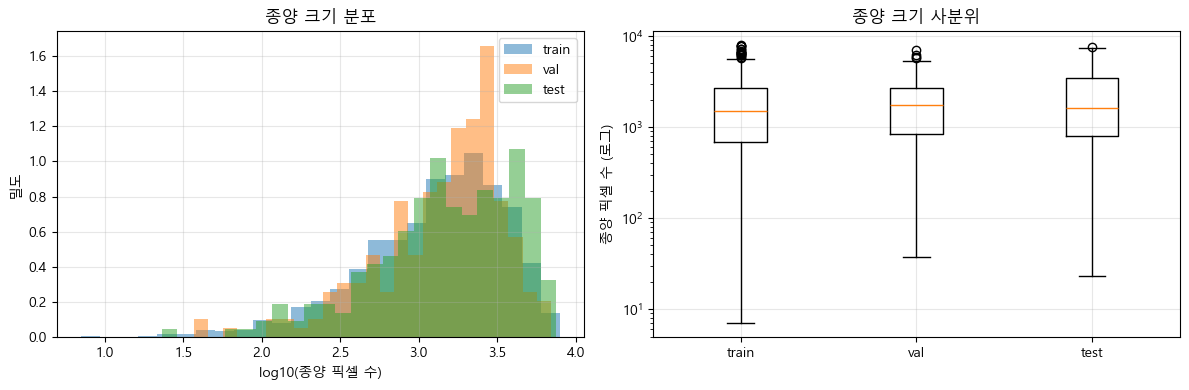

=== 층화하지 않은 변수 점검 ===
1) 종양 크기 중앙값 편차 17.4% -> 양호
2) 평균/중앙값 비  train 1.26 vs test 1.38
3) 최소 종양  train 7px / val 37px / test 23px
   -> val에 작은 종양이 없음. val에서 고른 임계값이 높게 잡혀
      test의 작은 종양을 놓칠 수 있음 -> 임계값 고원 중앙 선택이 특히 중요


In [13]:
# 종양 크기 분포 비교 + 자동 판정
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) 분포 모양 — 로그 스케일
for sp, c in [("train", "tab:blue"), ("val", "tab:orange"), ("test", "tab:green")]:
    v = pos.loc[pos.split == sp, "tumor_px"]
    axes[0].hist(np.log10(v), bins=25, alpha=0.5, density=True, label=sp, color=c)
axes[0].set_xlabel("log10(종양 픽셀 수)"); axes[0].set_ylabel("밀도")
axes[0].set_title("종양 크기 분포"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) 박스플롯
axes[1].boxplot([pos.loc[pos.split == sp, "tumor_px"] for sp in ["train", "val", "test"]],
                tick_labels=["train", "val", "test"])
axes[1].set_yscale("log"); axes[1].set_ylabel("종양 픽셀 수 (로그)")
axes[1].set_title("종양 크기 사분위"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 자동 판정 ---
print("=== 층화하지 않은 변수 점검 ===")
med = pos.groupby("split")["tumor_px"].median()
mean_ = pos.groupby("split")["tumor_px"].mean()
mn = pos.groupby("split")["tumor_px"].min()

gap = (med.max() - med.min()) / med.median()
print(f"1) 종양 크기 중앙값 편차 {gap:.1%}", "-> 양호" if gap < 0.25 else "-> 확인 필요")

skew_test = mean_["test"] / med["test"]
skew_train = mean_["train"] / med["train"]
print(f"2) 평균/중앙값 비  train {skew_train:.2f} vs test {skew_test:.2f}")
if skew_test > skew_train * 1.1:
    print("   -> test에 큰 종양이 치우쳐 있음. test 성능이 낙관적일 수 있음")

print(f"3) 최소 종양  train {mn['train']}px / val {mn['val']}px / test {mn['test']}px")
if mn["val"] > mn["test"] * 1.3:
    print("   -> val에 작은 종양이 없음. val에서 고른 임계값이 높게 잡혀")
    print("      test의 작은 종양을 놓칠 수 있음 -> 임계값 고원 중앙 선택이 특히 중요")

### 3-1. 정규화 통계

**[4번 변형]** 4번에서는 `IMAGENET_MEAN = [0.485, 0.456, 0.406]`을 그대로 썼다.
전이학습이라 사전학습 모델의 통계에 맞춰야 했기 때문이다.

**여기서는 쓰면 안 된다.** MRI는 뇌 바깥이 검은 배경이라 평균이 0.09 근처로 훨씬 낮고,
채널이 RGB가 아니라 서로 다른 촬영 기법이다. **train에서 직접 계산한다.**
(val/test까지 포함해 계산하면 데이터 누수다.)

**float64로 누적할 것.** 5억 개 픽셀을 float32로 더하면 반올림이 쌓여 평균이 2% 이상 틀어진다.

In [14]:
s, ss, n = np.zeros(3), np.zeros(3), 0
arr = data["train"][0]
for i in range(0, len(arr), 500):
    chunk = arr[i:i+500].astype(np.float64).reshape(-1, 3) / 255.0
    s  += chunk.sum(0, dtype=np.float64)
    ss += (chunk ** 2).sum(0, dtype=np.float64)
    n  += len(chunk)

MEAN = (s / n).astype(np.float32)
STD  = np.sqrt(ss / n - (s / n) ** 2).astype(np.float32)

print("채널: pre-contrast / FLAIR / post-contrast")
print("train mean:", MEAN.round(4), "  (ImageNet: [0.485 0.456 0.406])")
print("train std :", STD.round(4),  "  (ImageNet: [0.229 0.224 0.225])")

채널: pre-contrast / FLAIR / post-contrast
train mean: [0.0858 0.0822 0.0891]   (ImageNet: [0.485 0.456 0.406])
train std : [0.1302 0.1223 0.1301]   (ImageNet: [0.229 0.224 0.225])


---
## 4. Dataset / DataLoader

**[5번]** `SegDataset` 클래스 구조를 가져왔다.

```python
# 5번 원본
def __getitem__(self, i):
    img = self.images[i].astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    mask = torch.from_numpy(self.masks[i].astype(np.int64))   # 클래스 번호
    return torch.from_numpy(img), mask
```

바꾼 곳은 두 가지다.

1. **마스크 dtype** — `int64` 클래스 번호가 아니라 `float32` 0/1, shape도 `(1,H,W)`
2. **빈 슬라이스 재샘플링** [신규] — 매 에폭 다르게 뽑아 섞는다

증강은 **[2번]**의 `RandomHorizontalFlip` 개념을 numpy로 직접 구현했다.
`transforms`는 마스크를 같이 변형해주지 않기 때문이다.
이미지와 마스크에 **똑같이** 걸어야 하고, 정규화는 이미지에만 적용한다.

In [15]:
class SegDataset(Dataset):
    def __init__(self, imgs, msks, sub_df, neg_ratio=None, augment=False, seed=SEED):
        self.imgs, self.msks, self.sub = imgs, msks, sub_df
        self.neg_ratio, self.augment = neg_ratio, augment
        self.pos_idx = np.where(sub_df["tumor"].values == 1)[0]
        self.neg_idx = np.where(sub_df["tumor"].values == 0)[0]
        self.rng = np.random.default_rng(seed)
        self.resample_epoch()

    def resample_epoch(self):
        """[신규] 에폭마다 빈 슬라이스를 새로 뽑는다.
           데이터를 버리는 게 아니라 한 에폭 안의 비율만 조절한다."""
        if self.neg_ratio is None:                    # val / test는 전체 사용
            self.rows = np.arange(len(self.sub)); return
        k = min(int(len(self.pos_idx) * self.neg_ratio), len(self.neg_idx))
        pick = self.rng.choice(self.neg_idx, size=k, replace=False)
        self.rows = np.concatenate([self.pos_idx, pick])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        j = self.rows[i]
        img = self.imgs[j].astype(np.float32) / 255.0
        msk = self.msks[j].astype(np.float32)

        if self.augment:                              # 이미지·마스크 동시 변형
            if self.rng.random() < 0.5: img, msk = img[:, ::-1], msk[:, ::-1]
            if self.rng.random() < 0.5: img, msk = img[::-1],    msk[::-1]
            k = int(self.rng.integers(4))
            if k: img, msk = np.rot90(img, k), np.rot90(msk, k)
            img, msk = np.ascontiguousarray(img), np.ascontiguousarray(msk)

        img = np.transpose((img - MEAN) / STD, (2, 0, 1))   # 정규화는 이미지만
        return torch.from_numpy(img).float(), torch.from_numpy(msk)[None].float()


def make_loaders(neg_ratio=NEG_RATIO, augment=True, seed=SEED, batch=BATCH_SIZE):
    tr = SegDataset(*data["train"], neg_ratio=neg_ratio, augment=augment, seed=seed)
    va = SegDataset(*data["val"],   neg_ratio=None, augment=False)
    te = SegDataset(*data["test"],  neg_ratio=None, augment=False)
    kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return (tr,
            DataLoader(tr, batch_size=batch, shuffle=True,  **kw),
            DataLoader(va, batch_size=batch, shuffle=False, **kw),
            DataLoader(te, batch_size=batch, shuffle=False, **kw))

train_ds, train_loader, val_loader, test_loader = make_loaders()
xb, yb = next(iter(train_loader))
print(tuple(xb.shape), xb.dtype)
print(tuple(yb.shape), yb.dtype, "| 마스크 값:", yb.unique().tolist())
print("에폭당 학습 장수:", len(train_ds), f"(종양 {len(train_ds.pos_idx)} + 빈 슬라이스 일부)")

(16, 3, 256, 256) torch.float32
(16, 1, 256, 256) torch.float32 | 마스크 값: [0.0, 1.0]
에폭당 학습 장수: 1894 (종양 947 + 빈 슬라이스 일부)


---
## 5. U-Net

**[5번]** `conv2d_block` / `EncoderBlock` / `DecoderBlock` / `UNet` 구조를 그대로 가져왔다.
`_init_weights`의 `kaiming_normal_`도 **[2번]**의 `initializer_weights`와 같다.

바꾼 곳은 두 가지다.

1. **출력 채널 30 → 1** — **[4번]**에서 `nn.Linear(128, 1)`로 이진 출력을 만든 것과 같은 원리
2. **BatchNorm 추가** [2번] — Cityscapes처럼 클래스가 균형 잡힌 문제에서는 없어도 됐지만,
   종양 픽셀 1%인 여기서는 초반 수렴이 불안정하다

`use_bn=False`로 두면 5번 원본과 사실상 동일해진다. 이걸 **베이스라인 M1**으로 쓴다.

In [16]:
def conv2d_block(in_ch, out_ch, kernel_size=3, use_bn=True):
    layers = []
    for i in range(2):
        layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size,
                             padding=kernel_size // 2, bias=not use_bn)]
        if use_bn: layers += [nn.BatchNorm2d(out_ch)]     # [2번]
        layers += [nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.conv = conv2d_block(in_ch, out_ch, use_bn=use_bn)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        f = self.conv(x)
        return f, self.drop(self.pool(f))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2,
                                       padding=1, output_padding=1)
        self.drop = nn.Dropout(dropout)
        self.conv = conv2d_block(out_ch + skip_ch, out_ch, use_bn=use_bn)
    def forward(self, x, skip):
        return self.conv(self.drop(torch.cat([self.up(x), skip], dim=1)))


class UNet(nn.Module):
    def __init__(self, base=BASE, in_ch=3, n_classes=1, use_bn=True):
        super().__init__()
        b = base
        self.enc1 = EncoderBlock(in_ch, b,   use_bn=use_bn)
        self.enc2 = EncoderBlock(b,     b*2, use_bn=use_bn)
        self.enc3 = EncoderBlock(b*2,   b*4, use_bn=use_bn)
        self.enc4 = EncoderBlock(b*4,   b*8, use_bn=use_bn)
        self.bottleneck = conv2d_block(b*8, b*16, use_bn=use_bn)
        self.dec1 = DecoderBlock(b*16, b*8, b*8, use_bn=use_bn)
        self.dec2 = DecoderBlock(b*8,  b*4, b*4, use_bn=use_bn)
        self.dec3 = DecoderBlock(b*4,  b*2, b*2, use_bn=use_bn)
        self.dec4 = DecoderBlock(b*2,  b,   b,   use_bn=use_bn)
        self.out  = nn.Conv2d(b, n_classes, 1)
        self._init_weights()

    def _init_weights(self):                      # [2번] initializer_weights
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        f1, p1 = self.enc1(x); f2, p2 = self.enc2(p1)
        f3, p3 = self.enc3(p2); f4, p4 = self.enc4(p3)
        c = self.bottleneck(p4)
        c = self.dec1(c, f4); c = self.dec2(c, f3)
        c = self.dec3(c, f2); c = self.dec4(c, f1)
        return self.out(c)


_m = UNet()
with torch.no_grad():
    print("출력 shape:", tuple(_m(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)).shape))
print("파라미터  :", f"{sum(p.numel() for p in _m.parameters()):,}")
del _m

출력 shape: (1, 1, 256, 256)
파라미터  : 8,633,441


---
## 6. 손실함수

**[5번]** 은 `CrossEntropyLoss`를 썼다. 30개 클래스 중 하나를 고르는 문제였기 때문이다.
**[4번]** 은 이진이라 `BCEWithLogitsLoss`를 썼다.

여기는 이진이므로 4번 쪽이 맞지만, **BCE 단독은 위험하다.**
종양 픽셀이 1%라 "전부 배경"으로 답해도 손실이 충분히 낮아서
경사하강법 입장에서 종양을 찾을 이유가 없다.

그래서 **Dice 항을 섞는다** [신규]. `smooth=1.0`이 빈 마스크에서 0/0을 막는다.
정답 0, 예측 0이면 `(0+1)/(0+1)=1`이 되어 "잘 맞췄다"로 처리된다.

**AMP 주의** — 커스텀 손실은 내부에서 float32로 캐스팅해야 한다.
float16으로 65,536픽셀을 더하면 한계값 65,504를 넘어 분모가 inf가 되고,
손실이 1.0에 고정되어 학습이 멈춘다. 오류도 nan도 뜨지 않는다.

In [17]:
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()          # [4번]
        self.w, self.s = w_bce, smooth
    def forward(self, logits, target):
        logits, target = logits.float(), target.float()   # AMP 오버플로 방지
        bce = self.bce(logits, target)
        p = torch.sigmoid(logits)
        inter = (p * target).sum(dim=(1, 2, 3))
        den   = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice  = 1 - ((2*inter + self.s) / (den + self.s)).mean()
        return self.w * bce + (1 - self.w) * dice


class TverskyLoss(nn.Module):
    """beta > alpha 이면 놓침(FN)을 더 싫어한다 -> 재현율 중시.
       alpha=beta=0.5 이면 Dice와 동일."""
    def __init__(self, alpha=0.3, beta=0.7, smooth=1.0):
        super().__init__()
        self.a, self.b, self.s = alpha, beta, smooth
    def forward(self, logits, target):
        logits, target = logits.float(), target.float()
        p = torch.sigmoid(logits)
        tp = (p * target).sum(dim=(1, 2, 3))
        fp = (p * (1 - target)).sum(dim=(1, 2, 3))
        fn = ((1 - p) * target).sum(dim=(1, 2, 3))
        return (1 - (tp + self.s) / (tp + self.a*fp + self.b*fn + self.s)).mean()

### 6-1. Tversky 동작 검증

`beta`가 정말 놓침을 더 싫어하는지 확인한다.
**오차 픽셀 수를 같게 맞춘** 두 오답을 놓고 손실이 어느 쪽을 덜 싫어하는지 본다.

주의: `beta`가 다르면 손실함수 자체가 다르므로 **손실값끼리 비교하면 안 된다.**
학습 곡선 비교는 반드시 Dice 같은 공통 지표로 한다.

In [18]:
tgt   = torch.zeros(1, 1, 20, 20); tgt[0, 0, 5:13, 5:13] = 1.0      # 정답 64px
under = torch.full((1,1,20,20), -6.0); under[0,0,5:13,5:9]  = 6.0   # 놓침 32
over  = torch.full((1,1,20,20), -6.0); over[0,0,5:13,5:17]  = 6.0   # 오탐 32

print(f"{'설정':>20} {'과소예측':>10} {'과대예측':>10}   선호")
print("-" * 58)
for a, b in [(0.5,0.5), (0.3,0.7), (0.1,0.9), (0.7,0.3)]:
    lu = TverskyLoss(a,b)(under, tgt).item()
    lo = TverskyLoss(a,b)(over,  tgt).item()
    print(f"{'alpha=%.1f beta=%.1f' % (a,b):>20} {lu:>10.4f} {lo:>10.4f}   "
          f"{'과대예측(재현율↑)' if lo < lu else '과소예측(정밀도↑)'}")

                  설정       과소예측       과대예측   선호
----------------------------------------------------------
  alpha=0.5 beta=0.5     0.3322     0.2020   과대예측(재현율↑)
  alpha=0.3 beta=0.7     0.4070     0.1326   과대예측(재현율↑)
  alpha=0.1 beta=0.9     0.4667     0.0500   과대예측(재현율↑)
  alpha=0.7 beta=0.3     0.2358     0.2611   과소예측(정밀도↑)


### 6-2. 평가 지표

**[5번]** 의 `compute_miou`는 다중 클래스용이라 못 쓴다.
이진 분할용 Dice / IoU로 바꾼다.

슬라이스마다 따로 내서 평균 내지 않고 **교집합과 합을 누적한 뒤 마지막에 나눈다.**
슬라이스별 평균을 쓰면 종양 7픽셀짜리가 8,000픽셀짜리와 같은 무게를 갖는다.

In [19]:
def dice_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return (2*(p & t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return ((p & t).sum() + smooth) / ((p | t).sum() + smooth)

def pixel_recall(probs, trues, threshold=0.5):
    p, t = probs > threshold, trues > 0.5
    return (p & t).sum() / max(t.sum(), 1)

def volume_ratio(probs, trues, threshold=0.5):
    """예측 체적 / 정답 체적. 1.0이 정확, 2.0이면 2배 과대평가."""
    return (probs > threshold).sum() / max((trues > 0.5).sum(), 1)

### 6-3. 속도 측정

**[신규]** 에폭당 3분(180초) 기준을 맞추기 위해 본 학습 전에 잰다.
180초 안에 들어오는 것 중 `BASE`가 가장 큰 조합을 고른다.

In [48]:
import gc

def bench(base, batch, n_step=20, warmup=5):
    m = opt = xb = yb = None
    try:
        m    = UNet(base=base).to(device)
        opt  = torch.optim.Adam(m.parameters(), lr=1e-3)
        crit = BCEDiceLoss()
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
        xb = torch.randn(batch, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        yb = (torch.rand(batch, 1, IMAGE_SIZE, IMAGE_SIZE, device=device) > 0.98).float()

        m.train()
        for i in range(warmup + n_step):
            if i == warmup:
                if device.type == "cuda": torch.cuda.synchronize()
                t0 = time.time()
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = m(xb)
            loss = crit(logits, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        if device.type == "cuda": torch.cuda.synchronize()

        sec_step  = (time.time() - t0) / n_step
        epoch_sec = sec_step * int(np.ceil(len(train_ds) / batch))
        vram = torch.cuda.max_memory_allocated()/1024**3 if device.type=="cuda" else 0
        return epoch_sec, vram
    except torch.cuda.OutOfMemoryError:
        return None, None
    finally:
        del m, opt, xb, yb
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()


print(f"기준: {len(train_ds)}장 / {IMAGE_SIZE}px / AMP={USE_AMP} / 목표 180초\n")
print(f"{'base':>5} {'batch':>6} {'에폭추정':>10} {'VRAM':>9}   판정")
print("-" * 46)
for base in [64, 32, 16]:
    for batch in [8, 16]:
        sec, vram = bench(base, batch)
        if sec is None:
            print(f"{base:>5} {batch:>6} {'OOM':>10}")
        else:
            print(f"{base:>5} {batch:>6} {sec:>8.1f}초 {vram:>7.2f}GB   "
                  f"{'OK' if sec <= 180 else '초과'}")

기준: 1894장 / 256px / AMP=True / 목표 180초

 base  batch       에폭추정      VRAM   판정
----------------------------------------------
   64      8     43.0초    2.07GB   OK
   64     16     41.5초    3.68GB   OK
   32      8     16.0초    0.93GB   OK
   32     16     16.3초    1.73GB   OK
   16      8      6.8초    0.45GB   OK
   16     16      7.6초    0.85GB   OK


---
## 7. 베이스라인 M0 — 규칙 기반 (학습 없음)

**[2번 노트북의 SimpleDNN 자리]**

2번에서 `SimpleCNN`을 만들기 전에 `SimpleDNN`(완전연결층만)을 먼저 만들어
기준점을 잡았다. 여기서도 U-Net 이전에 **학습 없는 규칙 기반**을 먼저 세운다.

FLAIR 강도에 Otsu 임계값을 걸고 가장 큰 덩어리만 남긴다.
`cv2.threshold(THRESH_OTSU)`와 `connectedComponentsWithStats`는
수업에서 다루지 않은 함수이므로, numpy 백분위 방식과 비교해
왜 이쪽을 선택했는지 함께 기록한다.

이 결과가 있어야 두 가지를 숫자로 말할 수 있다.

1. **픽셀 정확도는 무의미하다** — 전부 배경이라 답해도 0.99가 나온다
2. **재현율 단독도 무의미하다** — 슬라이스 재현율 1.0인데 체적을 3.6배 과대평가한다
   → 재현율은 목표가 아니라 제약 조건으로 걸어야 한다

In [20]:
def otsu_predict(img_u8):
    flair = img_u8[:, :, 1]
    brain = flair > 12
    if brain.sum() < 500:
        return np.zeros_like(flair, np.uint8)
    t, _ = cv2.threshold(flair[brain], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pred = ((flair > t) & brain).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(pred, 8)
    if n <= 1: return pred
    k = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (lab == k).astype(np.uint8)

te_imgs, te_msks, te_sub = data["test"]
P0 = np.stack([otsu_predict(im) for im in te_imgs]).astype(np.float32)
f0 = (P0.sum(axis=(1,2)) > 20).astype(int)
t0_flag = te_sub["tumor"].values

print("=== M0 규칙 기반 (Otsu, 학습 없음) ===")
print(f"픽셀 Dice      {dice_score(P0, te_msks):.4f}")
print(f"픽셀 재현율    {pixel_recall(P0, te_msks):.4f}")
print(f"체적비         {volume_ratio(P0, te_msks):.2f}배")
print(f"슬라이스 recall {recall_score(t0_flag, f0, zero_division=0):.4f}  "
      f"precision {precision_score(t0_flag, f0, zero_division=0):.4f}")
print()
print("=== 무학습 하한선 ===")
print(f"전부 배경      -> Dice 0.0000, 픽셀 정확도 {1 - te_msks.mean():.4f}")
print(f"항상 종양 있음  -> 재현율 1.0000, 정밀도 {t0_flag.mean():.4f}")

=== M0 규칙 기반 (Otsu, 학습 없음) ===
픽셀 Dice      0.1487
픽셀 재현율    0.3445
체적비         3.64배
슬라이스 recall 1.0000  precision 0.3671

=== 무학습 하한선 ===
전부 배경      -> Dice 0.0000, 픽셀 정확도 0.9884
항상 종양 있음  -> 재현율 1.0000, 정밀도 0.3441


이 표가 두 가지를 동시에 증명한다.

1. **정확도는 무의미하다.** 아무것도 안 하는 모델이 픽셀 정확도 0.99를 낸다.
   4번에서 `accuracy_score`를 썼지만 여기서는 쓰면 안 되는 이유다.
2. **재현율 단독도 무의미하다.** Otsu의 슬라이스 재현율은 1.0이지만
   정밀도가 낮아 "무조건 종양 있음"이라 답한 것과 거의 같다.
   **재현율은 목표가 아니라 제약 조건으로 걸어야 한다.**

---
## 8. 학습 함수

**[5번 + 4번 결합]**

`train_unet`의 뼈대는 5번 그대로다. `history` 딕셔너리, `best_val` 체크포인트,
에폭별 출력까지 같은 구조다. 다만 세 곳을 바꿨다.

1. **체크포인트 기준** — 5번은 `if val_loss < best_val`이었다.
   여기서 val_loss나 픽셀 정확도로 저장하면 "전부 배경" 모델이 최고점으로 남는다.
   **`if val_dice > best_dice`로 뒤집는다.**
2. **train Dice 기록** — 과적합 격차를 보려면 loss만으로는 부족하다.
3. **AMP** [신규] — 1.5~2배 가속. 손실은 autocast 밖에서 계산한다.

`evaluate_seg`는 **[4번]**의 `evaluation()` 구조를 따랐다.
`model.eval()` → `@torch.no_grad()` → probs/trues 수집 → 지표 계산 순서다.
4번과 다른 점은 `sigmoid` 후 임계값을 씌운다는 것뿐이다.

In [21]:
@torch.no_grad()
def evaluate_seg(model, loader):
    """[4번 evaluation() 구조] 확률과 정답을 모아서 반환.
       5번의 evaluate_seg는 pixel accuracy를 반환했지만
       종양 픽셀이 1%인 여기서는 무의미하므로 확률 자체를 돌려준다."""
    model.eval()
    probs, trues = [], []
    for xb, yb in loader:
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb.to(device))
        probs.append(torch.sigmoid(logits.float()).cpu())
        trues.append(yb)
    return torch.cat(probs).numpy()[:, 0], torch.cat(trues).numpy()[:, 0]


def train_unet(criterion=None, neg_ratio=NEG_RATIO, seed=SEED, epochs=EPOCHS,
               lr=LR, augment=True, use_bn=True, tag="M2"):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_ds, tr_ld, va_ld, te_ld = make_loaders(neg_ratio, augment, seed)

    model  = UNet(base=BASE, use_bn=use_bn).to(device)
    crit   = criterion if criterion is not None else BCEDiceLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)   # [2번]
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = {"loss": [], "train_dice": [], "val_dice": [], "sec": []}
    best_dice, ckpt = -1.0, f"lgg_{tag}.pt"

    for epoch in range(1, epochs + 1):
        tr_ds.resample_epoch()               # 빈 슬라이스를 매 에폭 새로 뽑는다
        model.train()
        t0, run_loss = time.time(), 0.0
        inter = psum = tsum = 0.0

        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            loss = crit(logits, yb)                  # 손실은 autocast 밖 (float32)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()

            run_loss += loss.item() * xb.size(0)
            with torch.no_grad():                    # train Dice 누적
                p = (torch.sigmoid(logits.float()) > 0.5).float()
                inter += (p * yb).sum().item()
                psum  += p.sum().item(); tsum += yb.sum().item()

        sched.step()
        tr_loss = run_loss / len(tr_ds)
        tr_dice = 2*inter / max(psum + tsum, 1)
        vp, vt  = evaluate_seg(model, va_ld)
        va_dice = float(dice_score(vp, vt, 0.5))
        sec = time.time() - t0

        for k, v in zip(["loss","train_dice","val_dice","sec"],
                        [tr_loss, tr_dice, va_dice, sec]):
            history[k].append(v)

        star = ""
        if va_dice > best_dice:                      # 5번은 val_loss 최소였음
            best_dice = va_dice
            torch.save(model.state_dict(), ckpt)
            star = "  저장"
        print(f"[{tag}] {epoch:2d}/{epochs}  loss {tr_loss:.4f}  "
              f"train_dice {tr_dice:.4f}  val_dice {va_dice:.4f}  {sec:5.1f}초{star}")

    print(f"[{tag}] 최고 val Dice {best_dice:.4f} | "
          f"에폭 평균 {np.mean(history['sec']):.1f}초 | "
          f"과적합 격차 {history['train_dice'][-1] - history['val_dice'][-1]:+.4f}")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    return model, history

---
## 9. 모델 학습

가이드라인의 "최소 2개 이상 모델 비교"를 채운다.
**전부 수업에서 배운 구성요소만 조합했다.**

| 모델 | 구성 | 출처 |
|---|---|---|
| M0 | 규칙 기반 Otsu | cv2 [2번] |
| **M1** | U-Net + BCE만, BatchNorm 없음 | **5번 원본** — 베이스라인 |
| M2 | M1 + BatchNorm + BCE·Dice | BN은 [2번] |
| M3 | M2 + Tversky(β=0.7) | 재현율 강화 |

### M1 — 베이스라인 (5번 노트북 구조 그대로)

In [25]:
model_1, hist_1 = train_unet(criterion=nn.BCEWithLogitsLoss(),
                             use_bn=False, tag="M1")

[M1]  1/30  loss 0.0690  train_dice 0.3442  val_dice 0.5418   17.4초  저장
[M1]  2/30  loss 0.0369  train_dice 0.5151  val_dice 0.5278   17.9초
[M1]  3/30  loss 0.0325  train_dice 0.5581  val_dice 0.6291   18.1초  저장
[M1]  4/30  loss 0.0319  train_dice 0.5216  val_dice 0.6317   18.2초  저장
[M1]  5/30  loss 0.0292  train_dice 0.6108  val_dice 0.6338   18.2초  저장
[M1]  6/30  loss 0.0269  train_dice 0.6250  val_dice 0.6753   18.1초  저장
[M1]  7/30  loss 0.0274  train_dice 0.6165  val_dice 0.6814   18.2초  저장
[M1]  8/30  loss 0.0247  train_dice 0.6590  val_dice 0.6871   18.3초  저장
[M1]  9/30  loss 0.0235  train_dice 0.6683  val_dice 0.6615   18.3초
[M1] 10/30  loss 0.0227  train_dice 0.6863  val_dice 0.7228   18.4초  저장
[M1] 11/30  loss 0.0208  train_dice 0.7184  val_dice 0.7040   18.5초
[M1] 12/30  loss 0.0204  train_dice 0.7312  val_dice 0.7200   18.5초
[M1] 13/30  loss 0.0188  train_dice 0.7462  val_dice 0.7190   18.5초
[M1] 14/30  loss 0.0169  train_dice 0.7744  val_dice 0.6698   18.8초
[M1] 15/30  loss

26.9.4 이까지함 집에가서 마저할것.

### M2 — BatchNorm + BCE·Dice

In [22]:
model_2, hist_2 = train_unet(criterion=BCEDiceLoss(), use_bn=True, tag="M2")

[M2]  1/30  loss 0.5106  train_dice 0.4649  val_dice 0.1203   20.2초  저장
[M2]  2/30  loss 0.4099  train_dice 0.6308  val_dice 0.3419   19.4초  저장
[M2]  3/30  loss 0.3711  train_dice 0.6807  val_dice 0.5595   19.5초  저장
[M2]  4/30  loss 0.3619  train_dice 0.6645  val_dice 0.6853   17.3초  저장
[M2]  5/30  loss 0.3470  train_dice 0.7108  val_dice 0.6998   20.0초  저장
[M2]  6/30  loss 0.3407  train_dice 0.7299  val_dice 0.6477   19.8초
[M2]  7/30  loss 0.3118  train_dice 0.7346  val_dice 0.4557   20.3초
[M2]  8/30  loss 0.2136  train_dice 0.6422  val_dice 0.6574   20.0초
[M2]  9/30  loss 0.1936  train_dice 0.6685  val_dice 0.6342   20.2초
[M2] 10/30  loss 0.2210  train_dice 0.6110  val_dice 0.6272   20.1초
[M2] 11/30  loss 0.2039  train_dice 0.6249  val_dice 0.6271   19.9초
[M2] 12/30  loss 0.1957  train_dice 0.6550  val_dice 0.6565   19.9초
[M2] 13/30  loss 0.1718  train_dice 0.6973  val_dice 0.6742   19.9초
[M2] 14/30  loss 0.1751  train_dice 0.6762  val_dice 0.5742   19.9초
[M2] 15/30  loss 0.1686  tra

### M3 — Tversky (재현율 강화)

In [23]:
model_3, hist_3 = train_unet(criterion=TverskyLoss(alpha=0.3, beta=0.7),
                             use_bn=True, tag="M3")

[M3]  1/30  loss 0.8179  train_dice 0.1764  val_dice 0.3491   19.2초  저장
[M3]  2/30  loss 0.7170  train_dice 0.3123  val_dice 0.1696   19.3초
[M3]  3/30  loss 0.6746  train_dice 0.4408  val_dice 0.3649   19.5초  저장
[M3]  4/30  loss 0.6177  train_dice 0.4813  val_dice 0.1685   19.5초
[M3]  5/30  loss 0.4351  train_dice 0.4384  val_dice 0.3879   19.2초  저장
[M3]  6/30  loss 0.3594  train_dice 0.5036  val_dice 0.4374   19.5초  저장
[M3]  7/30  loss 0.3566  train_dice 0.5217  val_dice 0.5217   19.7초  저장
[M3]  8/30  loss 0.3389  train_dice 0.5391  val_dice 0.5547   19.6초  저장
[M3]  9/30  loss 0.3527  train_dice 0.5421  val_dice 0.0000   19.7초
[M3] 10/30  loss 0.4018  train_dice 0.4803  val_dice 0.4887   19.9초
[M3] 11/30  loss 0.3474  train_dice 0.5345  val_dice 0.4382   19.9초
[M3] 12/30  loss 0.3734  train_dice 0.5040  val_dice 0.5022   19.9초
[M3] 13/30  loss 0.3405  train_dice 0.5571  val_dice 0.4825   19.9초
[M3] 14/30  loss 0.4051  train_dice 0.4598  val_dice 0.5768   19.9초  저장
[M3] 15/30  loss 0.3

### 9-1. 학습 곡선

**[5번]** 의 loss 곡선 셀과 같은 방식.
다만 val Dice와 **과적합 격차**를 추가했다 (가이드라인 "train/test 성능 격차 확인").

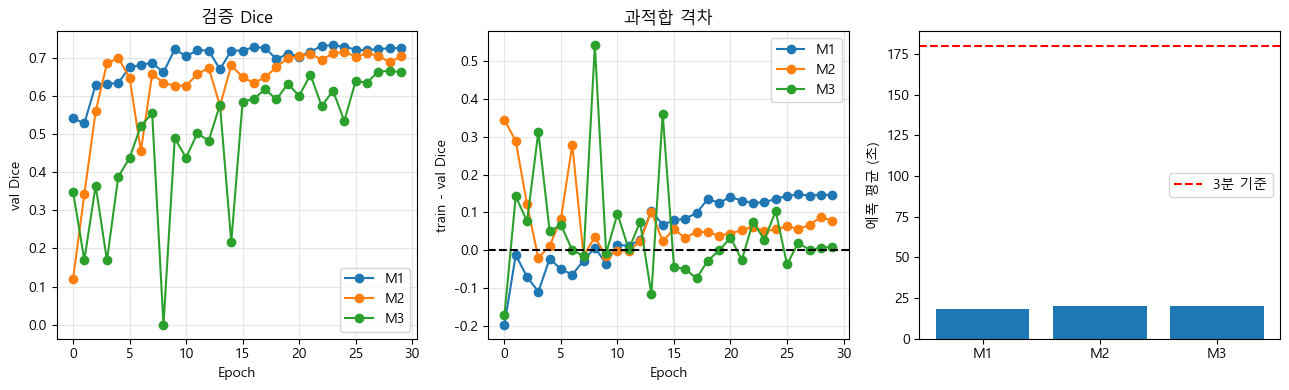

In [26]:
plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
for h, n in [(hist_1,"M1"), (hist_2,"M2"), (hist_3,"M3")]:
    plt.plot(h["val_dice"], marker="o", label=n)
plt.xlabel("Epoch"); plt.ylabel("val Dice"); plt.title("검증 Dice")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
for h, n in [(hist_1,"M1"), (hist_2,"M2"), (hist_3,"M3")]:
    plt.plot(np.array(h["train_dice"]) - np.array(h["val_dice"]), marker="o", label=n)
plt.axhline(0, ls="--", c="k"); plt.xlabel("Epoch"); plt.ylabel("train - val Dice")
plt.title("과적합 격차"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(["M1","M2","M3"], [np.mean(h["sec"]) for h in [hist_1,hist_2,hist_3]])
plt.axhline(180, ls="--", c="r", label="3분 기준")
plt.ylabel("에폭 평균 (초)"); plt.legend()
plt.tight_layout(); plt.show()

---
## 10. 임계값 결정

**[4번 확장]** 4번에서는 `sigmoid` 출력을 0.5로 잘랐다.
그런데 **0.5는 관습일 뿐 근거가 없다.** 종양이 희소해서 최적값이 더 낮은 쪽에 있다.

임계값만 바꿔도 지표가 크게 움직이는데, 이건 모델이 좋아진 게 아니라
정밀도-재현율 곡선 위에서 **서 있는 위치를 옮긴 것**이다.
그래서 모델 비교는 각 모델의 val 최적 임계값에서 해야 공정하다.

**val에서 정하고 test에 고정 적용한다.** test를 보고 고르면 누수다.
그리고 최고점이 아니라 **고원의 중앙**을 잡는다. val 환자가 적어
뾰족한 최고점을 잡으면 노이즈를 잡는 것이기 때문이다.

In [27]:
def threshold_sweep(probs, trues, ths=np.arange(0.05, 0.96, 0.05)):
    return pd.DataFrame([{"th": t,
                          "dice": dice_score(probs, trues, t),
                          "recall": pixel_recall(probs, trues, t),
                          "vol_ratio": volume_ratio(probs, trues, t)} for t in ths])

def pick_threshold(sw, tol=0.98):
    top = sw[sw["dice"] >= sw["dice"].max() * tol]
    return float(top["th"].median())

BEST_T = {}
for name, model in [("M1", model_1), ("M2", model_2), ("M3", model_3)]:
    vp, vt = evaluate_seg(model, val_loader)
    sw = threshold_sweep(vp, vt)
    BEST_T[name] = pick_threshold(sw)
    print(f"{name}: 최고점 {sw.loc[sw['dice'].idxmax(),'th']:.2f} / "
          f"고원 중앙 {BEST_T[name]:.2f} (val Dice {sw['dice'].max():.4f})")
    if name == "M2": sw_m2 = sw

M1: 최고점 0.40 / 고원 중앙 0.45 (val Dice 0.7347)
M2: 최고점 0.40 / 고원 중앙 0.47 (val Dice 0.7156)
M3: 최고점 0.80 / 고원 중앙 0.50 (val Dice 0.6675)


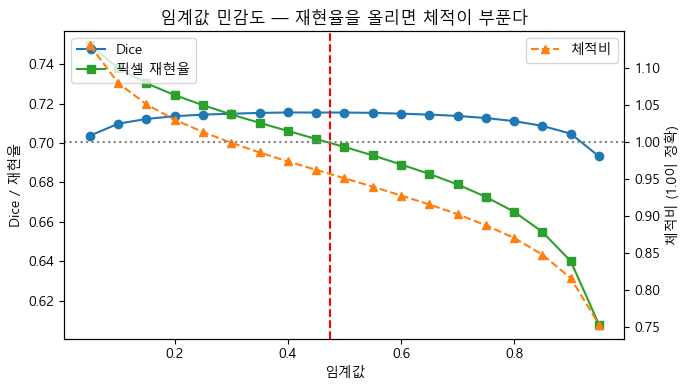

In [28]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sw_m2["th"], sw_m2["dice"],   "o-", color="tab:blue",  label="Dice")
ax1.plot(sw_m2["th"], sw_m2["recall"], "s-", color="tab:green", label="픽셀 재현율")
ax1.axvline(BEST_T["M2"], ls="--", c="r")
ax1.set_xlabel("임계값"); ax1.set_ylabel("Dice / 재현율"); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(sw_m2["th"], sw_m2["vol_ratio"], "^--", color="tab:orange", label="체적비")
ax2.axhline(1.0, ls=":", c="gray"); ax2.set_ylabel("체적비 (1.0이 정확)")
ax2.legend(loc="upper right")
plt.title("임계값 민감도 — 재현율을 올리면 체적이 부푼다")
plt.tight_layout(); plt.show()

---
## 11. 평가

**[4번]** 의 지표를 그대로 쓴다. `recall_score`, `precision_score`,
`roc_auc_score`, `confusion_matrix` 전부 4번에서 import했던 것이다.

다만 **`accuracy_score`는 빼야 한다.** M0에서 확인했듯 전부 배경이라 답해도
픽셀 정확도가 0.99라 아무 정보가 없다.

세 층위로 본다.

1. **픽셀** — Dice, IoU, 체적비
2. **슬라이스** — 4번의 이진 분류 지표 (예측 픽셀이 기준치를 넘으면 "종양 있음")
3. **환자** — 환자별 Dice + 놓친 슬라이스 번호

In [29]:
MIN_PX = 20      # 예측 픽셀이 이보다 많으면 "종양 있음" 판정

def evaluate_full(model, loader, sub_df, threshold, name=""):
    probs, trues = evaluate_seg(model, loader)
    has = sub_df["tumor"].values.astype(bool)

    # 1) 픽셀 수준
    d_all, d_pos = dice_score(probs, trues, threshold), dice_score(probs[has], trues[has], threshold)
    i_all, vol   = iou_score(probs, trues, threshold), volume_ratio(probs, trues, threshold)

    # 2) 슬라이스 수준  [4번 지표]
    pred_flag  = ((probs > threshold).sum(axis=(1,2)) > MIN_PX).astype(int)
    true_flag  = has.astype(int)
    slice_area = (probs > threshold).sum(axis=(1,2)) / IMAGE_SIZE**2
    rec   = recall_score(true_flag, pred_flag, zero_division=0)
    prec  = precision_score(true_flag, pred_flag, zero_division=0)
    f1    = f1_score(true_flag, pred_flag, zero_division=0)
    auc   = roc_auc_score(true_flag, slice_area)
    prauc = average_precision_score(true_flag, slice_area)
    cm    = confusion_matrix(true_flag, pred_flag)

    # 3) 환자 수준  [신규]
    per_patient, missed = {}, {}
    for p, gp in sub_df.groupby("patient"):
        k = gp.index.values
        per_patient[p] = float(dice_score(probs[k], trues[k], threshold))
        m = gp.loc[(true_flag[k] == 1) & (pred_flag[k] == 0), "slice"].tolist()
        if m: missed[p] = m

    pv = np.array(list(per_patient.values()))
    print(f"===== {name} (임계값 {threshold:.2f}) =====")
    print(f"[픽셀]    Dice {d_all:.4f} | 종양슬라이스만 {d_pos:.4f} | "
          f"IoU {i_all:.4f} | 체적비 {vol:.2f}배")
    print(f"[슬라이스] recall {rec:.4f} | precision {prec:.4f} | F1 {f1:.4f}")
    print(f"           ROC-AUC {auc:.4f} | PR-AUC {prauc:.4f} (임계값 무관)")
    print(f"[환자]    n={len(pv)} 평균 {pv.mean():.4f} 중앙값 {np.median(pv):.4f} "
          f"최소 {pv.min():.4f}")
    print(f"[놓침]    종양 슬라이스를 놓친 환자 {len(missed)}명 / {len(pv)}명")
    return dict(dice=float(d_all), dice_pos=float(d_pos), iou=float(i_all), vol=float(vol),
                recall=float(rec), precision=float(prec), f1=float(f1),
                auc=float(auc), prauc=float(prauc), cm=cm,
                per_patient=per_patient, missed=missed)

res = {}
for name, model in [("M1", model_1), ("M2", model_2), ("M3", model_3)]:
    res[name] = evaluate_full(model, test_loader, te_sub, BEST_T[name], name)
    print()

===== M1 (임계값 0.45) =====
[픽셀]    Dice 0.6684 | 종양슬라이스만 0.7271 | IoU 0.5020 | 체적비 0.99배
[슬라이스] recall 0.9346 | precision 0.8065 | F1 0.8658
           ROC-AUC 0.9356 | PR-AUC 0.8376 (임계값 무관)
[환자]    n=16 평균 0.6875 중앙값 0.7851 최소 0.0773
[놓침]    종양 슬라이스를 놓친 환자 8명 / 16명

===== M2 (임계값 0.47) =====
[픽셀]    Dice 0.6568 | 종양슬라이스만 0.6667 | IoU 0.4890 | 체적비 0.66배
[슬라이스] recall 0.6822 | precision 0.9299 | F1 0.7871
           ROC-AUC 0.8322 | PR-AUC 0.7735 (임계값 무관)
[환자]    n=16 평균 0.5644 중앙값 0.6683 최소 0.0000
[놓침]    종양 슬라이스를 놓친 환자 15명 / 16명

===== M3 (임계값 0.50) =====
[픽셀]    Dice 0.6438 | 종양슬라이스만 0.6714 | IoU 0.4748 | 체적비 0.77배
[슬라이스] recall 0.6822 | precision 0.8902 | F1 0.7725
           ROC-AUC 0.8214 | PR-AUC 0.7296 (임계값 무관)
[환자]    n=16 평균 0.5666 중앙값 0.6711 최소 0.0000
[놓침]    종양 슬라이스를 놓친 환자 13명 / 16명



In [30]:
# 모델 비교표 — 가이드라인 "여러 모델의 지표를 표로 비교"
cmp = pd.DataFrame({
    "M0 규칙기반": {"Dice": float(dice_score(P0, te_msks)), "체적비": float(volume_ratio(P0, te_msks)),
                    "슬라이스 recall": recall_score(t0_flag, f0, zero_division=0),
                    "PR-AUC": np.nan},
    **{f"{k} ": {"Dice": v["dice"], "체적비": v["vol"],
                 "슬라이스 recall": v["recall"], "PR-AUC": v["prauc"]}
       for k, v in res.items()}
}).T.round(4)
print(cmp.to_string())

           Dice     체적비  슬라이스 recall  PR-AUC
M0 규칙기반  0.1487  3.6355       1.0000     NaN
M1       0.6684  0.9913       0.9346  0.8376
M2       0.6568  0.6590       0.6822  0.7735
M3       0.6438  0.7698       0.6822  0.7296


### 11-1. 혼동행렬

**[2번]** 의 `seaborn` 히트맵 방식.

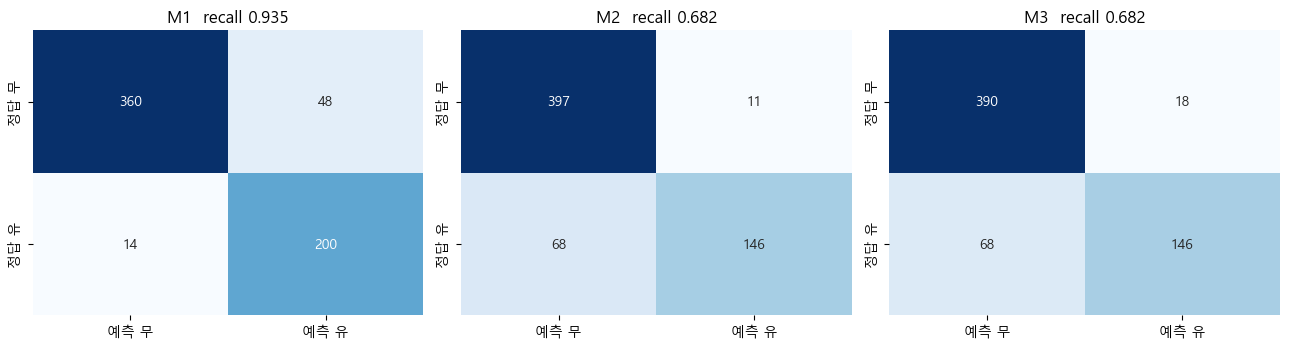

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (n, r) in zip(axes, res.items()):
    sns.heatmap(r["cm"], annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=["예측 무","예측 유"], yticklabels=["정답 무","정답 유"])
    ax.set_title(f"{n}  recall {r['recall']:.3f}")
plt.tight_layout(); plt.show()

### 11-2. 기관별 성능 분해

**[신규]** 기관마다 스캐너가 달라 밝기가 20~25% 차이 난다.
특정 기관에서만 성능이 낮다면 도메인 시프트 문제다.

In [32]:
BEST = max(res, key=lambda k: res[k]["dice"])
best_model = {"M1": model_1, "M2": model_2, "M3": model_3}[BEST]
best_t     = BEST_T[BEST]
print("최종 선정 모델:", BEST, f"(임계값 {best_t:.2f})\n")

pp = pd.Series(res[BEST]["per_patient"], name="dice").to_frame()
pp["inst"] = [p.split("_")[1] for p in pp.index]
print(pp.groupby("inst")["dice"].agg(["count", "mean", "min"]).round(4))

최종 선정 모델: M1 (임계값 0.45)

      count    mean     min
inst                       
CS        2  0.4773  0.0773
DU        7  0.6739  0.3800
FG        2  0.7224  0.6017
HT        5  0.7767  0.6052


### 11-3. 환자 1명 판독 리포트

**[신규]** 임상 전제의 핵심 산출물.
평균 Dice 0.83은 의사에게 아무 지시도 주지 못하지만,
"18번 슬라이스를 다시 보라"는 실행 가능한 정보다.

In [33]:
def patient_report(model, threshold, patient):
    probs, trues = evaluate_seg(model, test_loader)
    sub = te_sub[te_sub.patient == patient]
    k = sub.index.values
    p, t = probs[k], trues[k]
    pred_flag = ((p > threshold).sum(axis=(1,2)) > MIN_PX).astype(int)
    true_flag = sub["tumor"].values

    print(f"환자 {patient}  (기관 {patient.split('_')[1]}, 슬라이스 {len(sub)}장)")
    print("-" * 62)
    hit = int((pred_flag & true_flag).sum())
    print(f"[검출] 정답 종양 {true_flag.sum()}장 / 검출 {hit}장  "
          f"재현율 {hit/max(true_flag.sum(),1):.3f}")
    miss = sub.loc[(true_flag == 1) & (pred_flag == 0), ["slice", "tumor_px"]]
    fp   = sub.loc[(true_flag == 0) & (pred_flag == 1), "slice"].tolist()
    print("       놓친 슬라이스:",
          ", ".join(f"#{r.slice}({r.tumor_px}px)" for r in miss.itertuples())
          if len(miss) else "없음")
    print(f"       오탐 슬라이스: {fp if fp else '없음'}")
    print(f"[경계] Dice {dice_score(p,t,threshold):.4f}  IoU {iou_score(p,t,threshold):.4f}")
    print(f"[체적] 정답 {int((t>0.5).sum()):,}px  예측 {int((p>threshold).sum()):,}px  "
          f"{(volume_ratio(p,t,threshold)-1)*100:+.1f}%")

worst = min(res[BEST]["per_patient"], key=res[BEST]["per_patient"].get)
patient_report(best_model, best_t, worst)

환자 TCGA_CS_5397_20010315  (기관 CS, 슬라이스 22장)
--------------------------------------------------------------
[검출] 정답 종양 6장 / 검출 6장  재현율 1.000
       놓친 슬라이스: 없음
       오탐 슬라이스: [5, 6, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
[경계] Dice 0.0773  IoU 0.0402
[체적] 정답 5,078px  예측 109,864px  +2063.5%


---
## 12. 예측 결과 시각화

**[5번]** 의 마지막 셀과 같은 방식.
5번은 `사진 / 정답 / 모델 예측` 3열이었는데,
**맞춤·놓침·오탐을 색으로 구분한 겹쳐보기**를 4열로 추가했다.

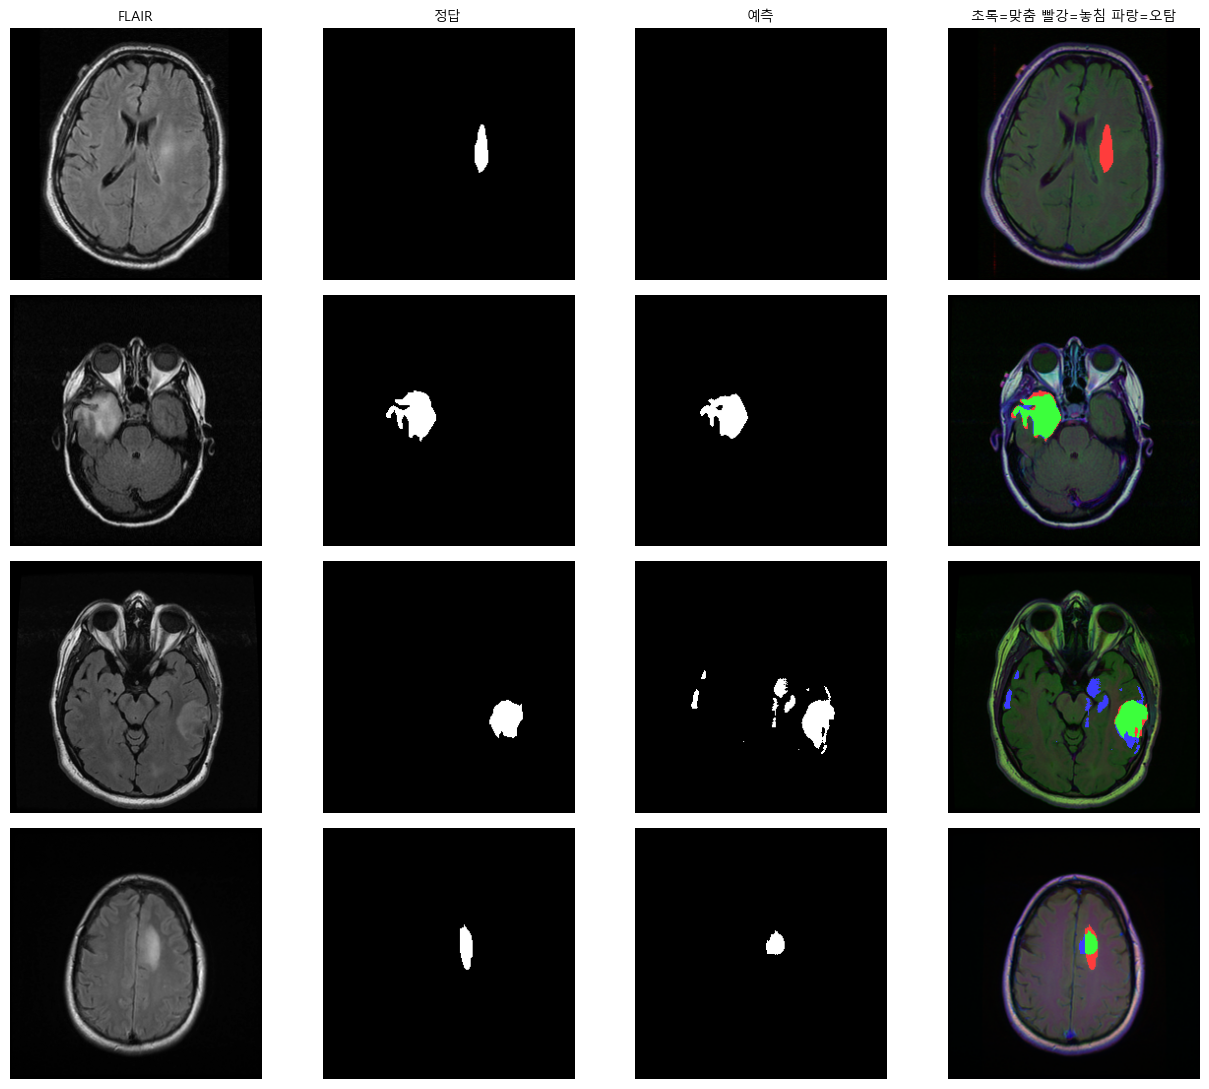

In [34]:
probs, trues = evaluate_seg(best_model, test_loader)
idx = te_sub.index[te_sub.tumor == 1]
idx = idx[::max(1, len(idx)//4)][:4]

plt.figure(figsize=(13, 11))
for r, i in enumerate(idx):
    img, msk = te_imgs[i], te_msks[i]
    pred = (probs[i] > best_t).astype(np.uint8)
    ov = img.copy()
    ov[(msk > 0) & (pred == 0)] = [255, 60, 60]     # 놓침
    ov[(msk == 0) & (pred == 1)] = [60, 60, 255]    # 오탐
    ov[(msk > 0) & (pred == 1)] = [60, 255, 60]     # 맞춤
    for j, (arr, t) in enumerate([(img[:,:,1], "FLAIR"), (msk, "정답"), (pred, "예측"),
                                  (ov, "초록=맞춤 빨강=놓침 파랑=오탐")]):
        plt.subplot(4, 4, r*4 + j + 1)
        plt.imshow(arr, cmap="gray" if arr.ndim == 2 else None); plt.axis("off")
        if r == 0: plt.title(t, fontsize=10)
plt.tight_layout(); plt.show()

---
## 13. 가설검정

**[신규]** 수업 범위 밖이지만 과제 요구사항이다.

> **H0**: M2와 M3(Tversky)의 환자별 Dice에 차이가 없다

**검정 단위는 환자이지 슬라이스가 아니다.** 같은 환자의 인접 슬라이스는
거의 같은 그림이라 독립 표본이 아니며, 슬라이스로 검정하면
차이가 없어도 p < 0.001이 나온다.

같은 환자를 두 모델이 각각 평가하므로 **대응표본**이다.
`scipy`를 쓰지 않고 **numpy만으로 정확 순열검정**을 한다.
환자 수가 n이면 부호 조합이 2^n가지라 n이 22 이하면 전수 계산이 가능하다.

In [ ]:
def exact_sign_test(diff):
    """대응표본 정확 순열검정 (부호 뒤집기 전수). numpy만 사용."""
    n = len(diff)
    if n > 22:
        raise ValueError("n이 크면 전수 계산 불가")
    signs = ((np.arange(2**n)[:, None] >> np.arange(n)) & 1) * 2 - 1
    null = (signs * np.abs(diff)).mean(axis=1)
    return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean())

def bootstrap_ci(diff, n_boot=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    b = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(n_boot)]
    return np.percentile(b, [2.5, 97.5])


pat  = sorted(res["M2"]["per_patient"].keys())
d_a  = np.array([res["M2"]["per_patient"][p] for p in pat])
d_b  = np.array([res["M3"]["per_patient"][p] for p in pat])
diff = d_b - d_a

p_val  = exact_sign_test(diff)
lo, hi = bootstrap_ci(diff)
eff    = (diff > 0).sum() / max((diff != 0).sum(), 1) * 2 - 1

print("=" * 56)
print(f"정확 순열검정 (대응표본, n = {len(pat)}명)")
print("=" * 56)
print(f"M2 중앙값 Dice       {np.median(d_a):.4f}")
print(f"M3 중앙값 Dice       {np.median(d_b):.4f}")
print(f"중앙값 차이 (M3-M2)  {np.median(diff):+.4f}")
print(f"M3가 나은 환자        {(diff > 0).sum()} / {len(pat)}")
print(f"p = {p_val:.4f}   효과크기 {eff:+.3f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
print()
print("판정:", "H0 기각 (유의수준 0.05)" if p_val < 0.05 else
      "H0 기각 실패 — '차이 없음'이 아니라 '차이를 확인하지 못함'")

정확 순열검정 (대응표본, n = 16명)
M2 중앙값 Dice       0.6683
M3 중앙값 Dice       0.6711
중앙값 차이 (M3-M2)  -0.0008
M3가 나은 환자        7 / 16
p = 0.9526   효과크기 -0.067   95% CI [-0.0565, +0.0713]

판정: H0 기각 실패 — '차이 없음'이 아니라 '차이를 확인하지 못함'


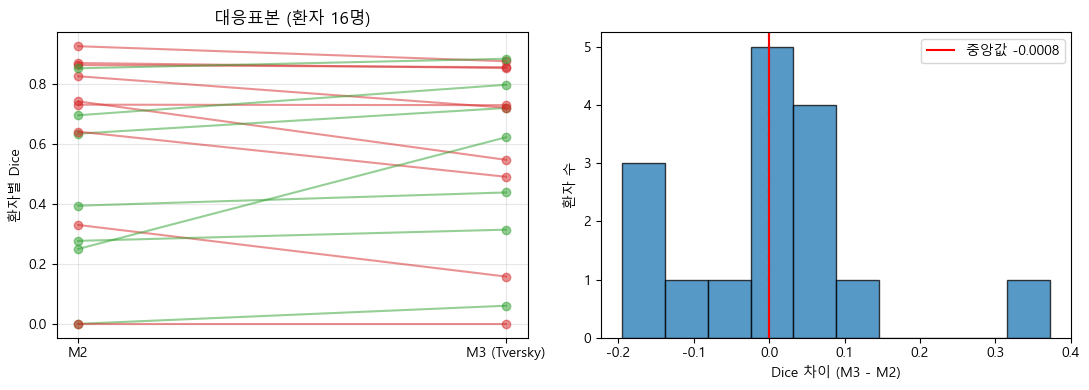

In [36]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for i in range(len(pat)):
    plt.plot([0, 1], [d_a[i], d_b[i]], "o-", alpha=0.5,
             color="tab:green" if diff[i] > 0 else "tab:red")
plt.xticks([0, 1], ["M2", "M3 (Tversky)"]); plt.ylabel("환자별 Dice")
plt.title(f"대응표본 (환자 {len(pat)}명)"); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(diff, bins=10, color="tab:blue", edgecolor="k", alpha=0.75)
plt.axvline(0, ls="--", c="k")
plt.axvline(np.median(diff), c="r", label=f"중앙값 {np.median(diff):+.4f}")
plt.xlabel("Dice 차이 (M3 - M2)"); plt.ylabel("환자 수"); plt.legend()
plt.tight_layout(); plt.show()

### 해석 시 주의

1. **n이 작으면 검정력이 낮다.** `p > 0.05`는 "차이 없음"이 아니라 "차이를 확인하지 못함".
2. p값만 쓰지 말고 **중앙값 차이, 효과크기, 신뢰구간**을 함께 보고한다.
3. **test는 여기서 끝이다.** 결과를 보고 설정을 바꿔 다시 돌리면 선택 편향이 들어간다.

---
## 14. 결과 저장

`results.json`으로 저장한다. 보고서 작성 시 그대로 인용.

In [37]:
summary = {
    "환경": ENV,
    "설정": {"BASE": BASE, "IMAGE_SIZE": IMAGE_SIZE, "BATCH": BATCH_SIZE,
             "EPOCHS": EPOCHS, "NEG_RATIO": NEG_RATIO, "AMP": USE_AMP},
    "분할": {sp: {"환자": int(df[df.split==sp]["patient"].nunique()),
                  "슬라이스": int((df.split==sp).sum())}
             for sp in ["train","val","test"]},
    "에폭평균초": {k: float(np.mean(h["sec"]))
                   for k, h in [("M1",hist_1),("M2",hist_2),("M3",hist_3)]},
    "임계값": BEST_T,
    "결과": {k: {kk: vv for kk, vv in v.items()
                 if kk not in ("cm","per_patient","missed")} for k, v in res.items()},
    "최종모델": BEST,
    "검정": {"n": len(pat), "p": p_val, "중앙값차이": float(np.median(diff)),
             "효과크기": float(eff), "CI95": [float(lo), float(hi)]},
}
with open("results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "환경": {
    "OS": "Windows 10",
    "Python": "3.10.11",
    "torch": "2.11.0+cu128",
    "CUDA": "12.8",
    "GPU": "NVIDIA GeForce RTX 5060 Laptop GPU",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "opencv": "4.11.0",
    "sklearn": "1.7.2",
    "matplotlib": "3.10.9",
    "SEED": 42
  },
  "설정": {
    "BASE": 32,
    "IMAGE_SIZE": 256,
    "BATCH": 16,
    "EPOCHS": 30,
    "NEG_RATIO": 1.0,
    "AMP": true
  },
  "분할": {
    "train": {
      "환자": 78,
      "슬라이스": 2742
    },
    "val": {
      "환자": 16,
      "슬라이스": 565
    },
    "test": {
      "환자": 16,
      "슬라이스": 622
    }
  },
  "에폭평균초": {
    "M1": 18.48921992778778,
    "M2": 19.90906913280487,
    "M3": 19.936194149653115
  },
  "임계값": {
    "M1": 0.45,
    "M2": 0.475,
    "M3": 0.5
  },
  "결과": {
    "M1": {
      "dice": 0.6684259964273302,
      "dice_pos": 0.7271116620053738,
      "iou": 0.501981861041476,
      "vol": 0.9912929605621091,
      "recall": 0.9345794392523364,
      "precision": 0.80645161